# 06 Hyperparameter Tuning (Optuna + MLflow)

This notebook tunes model hyperparameters with reproducible Optuna studies and nested MLflow trial logging.

## LFD Anchors
- Validation discipline: model selection is based on train/validation performance only.
- Data snooping prevention: the test split is not used inside the optimization objective.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import optuna
import pandas as pd
from optuna.visualization.matplotlib import plot_optimization_history, plot_param_importances

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT / "src"))

/home/amir/dev/lol-match-oracle/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from oracle.models import TrainingConfig
from oracle.optimization import OptimizationConfig, run_model_optimization
from oracle.utils import load_yaml_config

training_mapping = load_yaml_config(PROJECT_ROOT / "configs" / "training.yaml")
model_mapping = load_yaml_config(PROJECT_ROOT / "configs" / "model.yaml")

training_config = TrainingConfig.from_mapping(
    training_mapping,
    base_dir=PROJECT_ROOT,
    experiment_name_override="02-advanced-models",
    run_name_override="notebook-optuna-best-model",
)
optimization_config = OptimizationConfig.from_mapping(
    model_mapping,
    base_dir=PROJECT_ROOT,
)
optimization_config.n_trials = 20

In [3]:
result = run_model_optimization(
    model_name="random_forest",
    training_config=training_config,
    model_mapping=model_mapping,
    optimization_config=optimization_config,
)

result

2026/04/21 17:12:04 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/04/21 17:12:04 INFO mlflow.store.db.utils: Updating database tables
2026/04/21 17:12:07 INFO mlflow.tracking.fluent: Experiment with name '03-optuna-tuning' does not exist. Creating a new experiment.
[I 2026-04-21 17:12:07,800] A new study created in RDB with name: lfd-optuna-random_forest
[I 2026-04-21 17:12:59,050] Trial 0 finished with value: 0.9992578692444107 and parameters: {'n_estimators': 350, 'max_depth': 20, 'min_samples_split': 8, 'min_samples_leaf': 3}. Best is trial 0 with value: 0.9992578692444107.
[I 2026-04-21 17:13:15,395] Trial 1 finished with value: 0.9985282471496302 and parameters: {'n_estimators': 200, 'max_depth': 6, 'min_samples_split': 2, 'min_samples_leaf': 5}. Best is trial 0 with value: 0.9992578692444107.
[I 2026-04-21 17:14:26,857] Trial 2 finished with value: 0.9992314921504621 and parameters: {'n_estimators': 550, 'max_depth': 16, 'min_samples_split': 2, 'min_

OptimizationResult(model_name='random_forest', study_name='lfd-optuna-random_forest', parent_run_id='03a85ce767a7483288c1f616527de49e', best_value=0.9992595712935307, best_params={'n_estimators': 350, 'max_depth': 18, 'min_samples_split': 9, 'min_samples_leaf': 2, 'class_weight': 'balanced_subsample', 'n_jobs': -1}, initial_trials=0, total_trials=20, added_trials=20, best_model_path=PosixPath('/home/amir/dev/lol-match-oracle/models/02-advanced-models/random_forest/03a85ce767a7483288c1f616527de49e/model.pkl'), best_params_path=PosixPath('/home/amir/dev/lol-match-oracle/reports/optimization/lfd-optuna-random_forest_best_params.json'), best_model_metadata_path=PosixPath('/home/amir/dev/lol-match-oracle/reports/optimization/lfd-optuna-random_forest_best_model_metadata.json'), study_summary_path=PosixPath('/home/amir/dev/lol-match-oracle/reports/optimization/lfd-optuna-random_forest_study_summary.json'), storage_url='sqlite:///optuna_studies.db')

In [4]:
summary = pd.DataFrame(
    [
        {
            "model": result.model_name,
            "study_name": result.study_name,
            "best_value": result.best_value,
            "initial_trials": result.initial_trials,
            "total_trials": result.total_trials,
            "added_trials": result.added_trials,
            "parent_run_id": result.parent_run_id,
        }
    ]
)
summary

,model,study_name,best_value,initial_trials,total_trials,added_trials,parent_run_id
0,random_forest,lfd-optuna-random_forest,0.99926,0,20,20,03a85ce767a7483288c1f616527de49e


/tmp/ipykernel_44228/4209091706.py:3: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  plot_optimization_history(study)
/tmp/ipykernel_44228/4209091706.py:4: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  plot_param_importances(study)


<Axes: title={'left': 'Hyperparameter Importances'}, xlabel='Hyperparameter Importance', ylabel='Hyperparameter'>

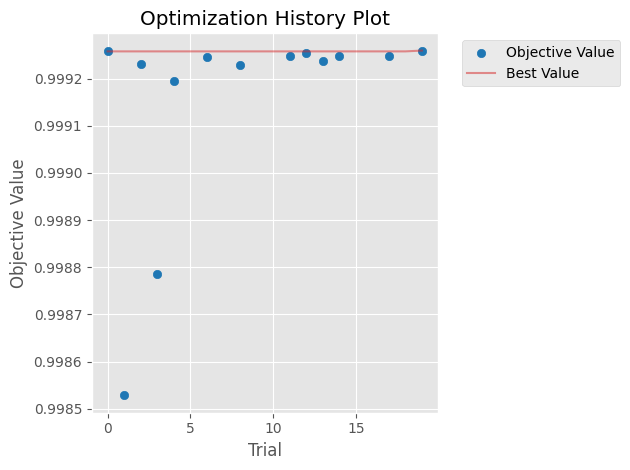

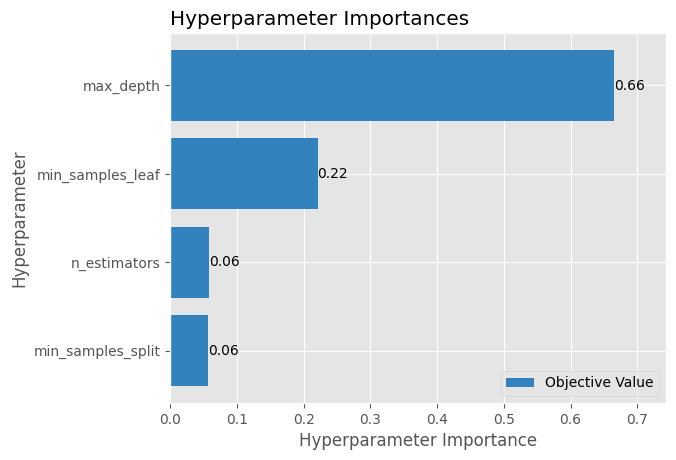

In [9]:
study = optuna.load_study(study_name=result.study_name, storage=result.storage_url)

plot_optimization_history(study)
plot_param_importances(study)

## Interpretation Notes
- If `initial_trials` is greater than zero, the study resumed from previous SQLite state.
- The optimization objective uses validation performance (`val_roc_auc`) and avoids test feedback during tuning.
- After selecting best hyperparameters, the pipeline trains and evaluates once on test for a final generalization estimate.